In [1]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
import random

def generate_isomer_dataset(num_samples_per_class=1000):
    """
    Generates a synthetic dataset of dichlorobenzene isomers.
    Ensures topological relevance as node features are identical across classes.
    """
    
    # Base SMILES for the three isomers
    # Using explicit H to ensure consistent numbering before sanitization, 
    # though RDKit usually handles this fine.
    smiles_templates = {
        0: 'Clc1c(Cl)cccc1', # Ortho
        1: 'Clc1cc(Cl)ccc1', # Meta
        2: 'Clc1ccc(Cl)cc1'  # Para
    }

    dataset = []

    print(f"Generating {num_samples_per_class * 3} total graphs...")

    for class_label, smiles in smiles_templates.items():
        for _ in range(num_samples_per_class):
            # 1. Create Molecule
            mol = Chem.MolFromSmiles(smiles)
            # Add explicit hydrogens then remove them to standardise/randomise layout slightly
            mol = Chem.AddHs(mol)
            mol = Chem.RemoveHs(mol)
            
            # Sanity check to ensure it parsed correctly
            if mol is None: continue

            # 2. Identify Ground Truth Nodes
            # The GT nodes are the 2 Cl atoms AND the 2 Ring Carbons they attach to.
            gt_node_indices = set()
            cl_atoms = []
            
            # Find the Chlorine atoms
            for atom in mol.GetAtoms():
                if atom.GetSymbol() == 'Cl':
                    cl_atoms.append(atom)
                    gt_node_indices.add(atom.GetIdx())
            
            # Find the anchor carbons on the ring
            for cl_atom in cl_atoms:
                # Cl will only have one neighbor: the ring carbon
                neighbor = cl_atom.GetNeighbors()[0]
                gt_node_indices.add(neighbor.GetIdx())
            
            # Verification check (should always be 4 nodes for dichlorobenzene)
            assert len(gt_node_indices) == 4, f"Error in GT definition for class {class_label}"

            # 3. Store Data object
            # You will need to convert this RDKit mol to your GNN framework's data object later.
            data_point = {
                'rdkit_mol': mol,
                'smiles_debug': Chem.MolToSmiles(mol), # For verification
                'label': class_label,
                'gt_important_nodes': list(gt_node_indices) # List of indices [0, 1, 7, 8] etc.
            }
            dataset.append(data_point)

    # Shuffle dataset
    random.shuffle(dataset)
    print("Generation complete.")
    return dataset

# =========================================
# Execution and Verification
# =========================================
full_dataset = generate_isomer_dataset(num_samples_per_class=5) # Small run for testing

# Let's inspect one sample to understand what you'll feed your model
sample = full_dataset[0]
mol = sample['rdkit_mol']
label_map = {0: 'Ortho', 1: 'Meta', 2: 'Para'}

print(f"\n--- Sample Inspection ---")
print(f"SMILES: {sample['smiles_debug']}")
print(f"Label: {sample['label']} ({label_map[sample['label']]})")
print(f"Ground Truth Important Node Indices: {sample['gt_important_nodes']}")

# Visual verification of atom mapping (optional, requires running locally)
# To see which nodes correspond to the indices:
# from rdkit.Chem.Draw import IPythonConsole
# mol_with_indices = Chem.Mol(mol)
# for atom in mol_with_indices.GetAtoms():
#     atom.SetAtomMapNum(atom.GetIdx())
# display(mol_with_indices)

Generating 15 total graphs...
Generation complete.

--- Sample Inspection ---
SMILES: Clc1ccc(Cl)cc1
Label: 2 (Para)
Ground Truth Important Node Indices: [0, 1, 4, 5]


In [7]:
import sys
from pathlib import Path

current_dir = Path.cwd()

project_root = current_dir.parents[2] 

if str(project_root) not in sys.path:
    
    sys.path.append(str(project_root))

print(f"Project root added: {project_root}")

Project root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


# ZINC + Dichlorobenzene (Needle-in-a-Haystack)
This section builds a **triplet-per-scaffold** dataset for **3-class** graph classification (ortho/meta/para).
It is designed to be **RINGS-friendly** (anti-cheating): the same scaffold produces three graphs, differing only in the isomer motif topology.

Ground-truth masks for explanation evaluation are stored per graph:
- `node_mask` (4 core nodes) and `node_mask_full` (8 motif nodes)
- `edge_mask` (C–Cl bonds) and `edge_mask_full` (ring + C–Cl bonds)

In [10]:
from collections import Counter
import torch

from bcosgnn.data.zinc_dichloro import BuildConfig, build_zinc_dichloro_dataset, save_dataset_splits

In [11]:
# Small sanity build (fast). For full build, use scripts/build_zinc_dichloro_dataset.py
cfg = BuildConfig(
    num_scaffolds=10,
    seed=0,
    min_total_atoms=30,
    max_total_atoms=50,
    max_degree=6,
    train_frac=0.8,
    val_frac=0.1,
    use_rings_zinc_pickles=False,  # set True to source scaffolds from local RINGS ZINC pickles
    fallback_random_alkanes=True,
 )
splits = build_zinc_dichloro_dataset(cfg)
{k: len(v) for k, v in splits.items()}

{'train': 24, 'val': 3, 'test': 3}

In [12]:
# Class balance check (0/1/2 == ortho/meta/para)
ys = []
for split_name, ds in splits.items():
    ys.extend([int(d.y.item()) for d in ds])
Counter(ys)

Counter({0: 10, 1: 10, 2: 10})

In [13]:
# Inspect one example and verify mask sizes
ex = splits["train"][0]
print(ex)
print("x", tuple(ex.x.shape), "edge_index", tuple(ex.edge_index.shape), "edge_attr", None if ex.edge_attr is None else tuple(ex.edge_attr.shape))
print("node_mask sum", int(ex.node_mask.sum().item()), "node_mask_full sum", int(ex.node_mask_full.sum().item()))
print("edge_mask sum", int(ex.edge_mask.sum().item()), "edge_mask_full sum", int(ex.edge_mask_full.sum().item()))

Data(x=[42, 7], edge_index=[2, 84], edge_attr=[84, 6], y=[1], node_mask=[42, 1], scaffold_id=[1], node_mask_full=[42, 1], edge_mask=[84, 1], edge_mask_full=[84, 1])
x (42, 7) edge_index (2, 84) edge_attr (84, 6)
node_mask sum 4 node_mask_full sum 8
edge_mask sum 4 edge_mask_full sum 16


## Visualize a few graphs
Below: a simple NetworkX + Matplotlib visualization of PyG `Data` objects, with motif ground-truth highlighted.

In [18]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

def _masked_undirected_edge_set(data, edge_mask_attr: str) -> set[tuple[int, int]]:
    if not hasattr(data, edge_mask_attr):
        return set()
    m = getattr(data, edge_mask_attr).view(-1).bool()
    ei = data.edge_index
    pairs = set()
    idxs = torch.where(m)[0].tolist()
    for j in idxs:
        u = int(ei[0, j].item())
        v = int(ei[1, j].item())
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        pairs.add((a, b))
    return pairs

def _motif_cycle_and_cls(data, node_mask_attr: str, edge_mask_attr: str):
    motif_nodes = []
    if hasattr(data, node_mask_attr):
        motif_nodes = torch.where(getattr(data, node_mask_attr).view(-1).bool())[0].tolist()
    if not motif_nodes:
        return [], [], []

    masked_edges = _masked_undirected_edge_set(data, edge_mask_attr)
    Gm = nx.Graph()
    Gm.add_nodes_from(motif_nodes)
    for (u, v) in masked_edges:
        if u in Gm and v in Gm:
            Gm.add_edge(u, v)

    cycles = nx.cycle_basis(Gm)
    ring = []
    for c in cycles:
        if len(c) == 6:
            ring = c
            break
    if not ring and cycles:
        ring = max(cycles, key=len)

    ring_set = set(ring)
    cls = [n for n in motif_nodes if n not in ring_set]
    return ring, cls, motif_nodes

def _circle_positions(nodes: list[int], radius: float = 1.0, phase: float = 0.0) -> dict[int, tuple[float, float]]:
    import math
    if not nodes:
        return {}
    out = {}
    for i, n in enumerate(nodes):
        theta = phase + 2.0 * math.pi * i / len(nodes)
        out[n] = (radius * math.cos(theta), radius * math.sin(theta))
    return out

def _cycle_order(G: nx.Graph, cycle_nodes: list[int]) -> list[int]:
    if not cycle_nodes:
        return []
    s = set(cycle_nodes)
    # Walk the cycle to get a consistent order
    start = cycle_nodes[0]
    order = [start]
    prev = None
    cur = start
    for _ in range(len(cycle_nodes) - 1):
        nbrs = [n for n in G.neighbors(cur) if n in s and n != prev]
        if not nbrs:
            break
        nxt = nbrs[0]
        order.append(nxt)
        prev, cur = cur, nxt
    return order if len(order) == len(cycle_nodes) else cycle_nodes

def plot_pyg_graph(
    data,
    *,
    ax=None,
    title: str | None = None,
    node_mask_attr: str = "node_mask_full",
    edge_mask_attr: str = "edge_mask_full",
    seed: int = 0,
    node_size: int = 70,
    motif_node_size: int = 140,
 ):
    G = to_networkx(data, to_undirected=True)
    ax = ax or plt.gca()

    ring, cls, motif_nodes = _motif_cycle_and_cls(data, node_mask_attr, edge_mask_attr)
    fixed_pos = {}
    fixed_nodes = []

    if ring:
        # Build motif-only graph for ordering/neighbor queries
        masked_edges = _masked_undirected_edge_set(data, edge_mask_attr)
        Gm = nx.Graph()
        Gm.add_nodes_from(motif_nodes)
        for (u, v) in masked_edges:
            if u in Gm and v in Gm:
                Gm.add_edge(u, v)

        ring_order = _cycle_order(Gm, ring)
        fixed_pos.update(_circle_positions(ring_order, radius=1.2, phase=0.0))
        fixed_nodes.extend(ring_order)

        # Place Cl nodes (or any non-ring motif nodes) outside their attached ring carbon
        for cl in cls:
            nbrs = [n for n in Gm.neighbors(cl) if n in fixed_pos]
            if not nbrs:
                continue
            anchor = nbrs[0]
            ax_x, ax_y = fixed_pos[anchor]
            # push outward from origin
            norm = (ax_x**2 + ax_y**2) ** 0.5 or 1.0
            fixed_pos[cl] = (ax_x * 1.45 / norm, ax_y * 1.45 / norm)
            fixed_nodes.append(cl)

        # Layout full graph with motif nodes fixed
        pos = nx.spring_layout(G, seed=seed, pos=fixed_pos, fixed=fixed_nodes)
    else:
        pos = nx.spring_layout(G, seed=seed)

    node_mask = getattr(data, node_mask_attr).view(-1).bool() if hasattr(data, node_mask_attr) else None
    node_colors = []
    node_sizes = []
    for n in G.nodes():
        is_motif = bool(node_mask[n].item()) if node_mask is not None else False
        node_colors.append("tab:red" if is_motif else "lightgray")
        node_sizes.append(motif_node_size if is_motif else node_size)

    masked_edges = _masked_undirected_edge_set(data, edge_mask_attr)
    edge_colors = []
    edge_widths = []
    for (u, v) in G.edges():
        a, b = (u, v) if u < v else (v, u)
        if (a, b) in masked_edges:
            edge_colors.append("tab:red")
            edge_widths.append(2.4)
        else:
            edge_colors.append("gray")
            edge_widths.append(0.5)

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths, alpha=0.9)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, linewidths=0.0)

    # Label motif nodes so ortho/meta/para is visible.
    labels = {}
    if ring:
        ring_order = [n for n in fixed_nodes if n in set(ring)]
        for i, n in enumerate(ring_order):
            labels[n] = str(i)
        for cl in cls:
            labels[cl] = "Cl"
    else:
        if motif_nodes:
            for n in motif_nodes:
                labels[n] = str(n)

    if labels:
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_color="black", ax=ax)

    ax.set_axis_off()
    if title:
        ax.set_title(title)

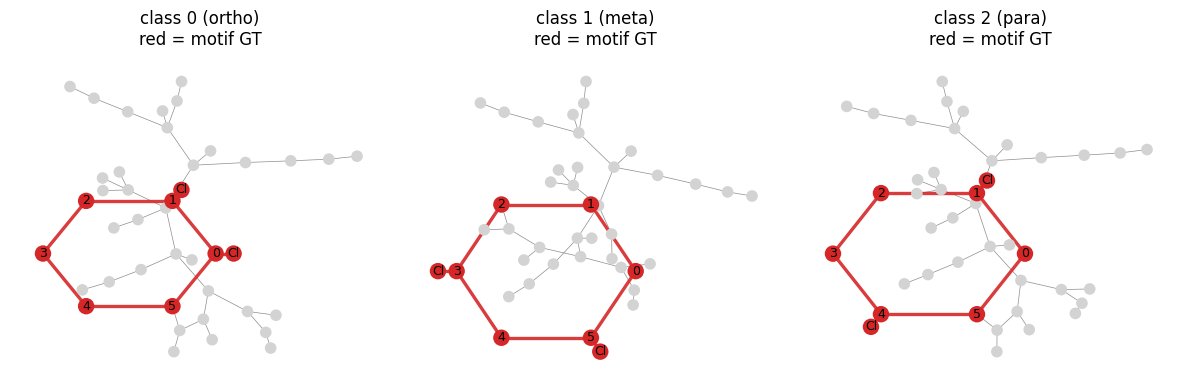

In [19]:
# Plot one example per class from train split
by_class = {}
for d in splits["train"]:
    y = int(d.y.item())
    if y not in by_class:
        by_class[y] = d
    if len(by_class) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
label_map = {0: "ortho", 1: "meta", 2: "para"}
for i, y in enumerate([0, 1, 2]):
    d = by_class[y]
    plot_pyg_graph(
        d,
        ax=axes[i],
        title=f"class {y} ({label_map[y]})\nred = motif GT",
        node_mask_attr="node_mask_full",
        edge_mask_attr="edge_mask_full",
        seed=0,
    )
plt.tight_layout()
plt.show()

In [15]:
# Save/load example (matches scripts/build_zinc_dichloro_dataset.py output path)
out_path = "data/zinc_dichloro/processed/splits.pt"
save_dataset_splits(splits, out_path)

# NOTE: PyTorch>=2.6 defaults `weights_only=True`; for dataset objects we need `weights_only=False`.
splits2 = torch.load(out_path, map_location="cpu", weights_only=False)
{k: len(v) for k, v in splits2.items()}

{'train': 24, 'val': 3, 'test': 3}

In [20]:
d = splits["train"][0]
motif = set(torch.where(d.node_mask_full.view(-1).bool())[0].tolist())
scaffold = set(range(d.num_nodes)) - motif
print("motif ∩ scaffold =", motif & scaffold)

# count edges that connect scaffold<->motif (should be small; includes the attachment bond)
ei = d.edge_index
cross = 0
for j in range(ei.size(1)):
    u, v = int(ei[0, j]), int(ei[1, j])
    if (u in motif) ^ (v in motif):
        cross += 1
print("directed cross edges:", cross)

motif ∩ scaffold = set()
directed cross edges: 2
